In [1]:
import pandas as pd
import numpy as np
import re
import ast
from typing import Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


### Configuration and constants

In [2]:
class Config:
    # Data paths
    TRAIN1_PATH = "../dataset/train1.csv"
    TRAIN2_PATH = "../dataset/train2.csv"
    
    # Text processing
    MAX_FEATURES = 5000
    EMBEDDING_DIM = 128
    MAX_LENGTH = 512
    
    # Training
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 10
    
    # Feature engineering
    UNIT_MAPPING = {
        'ounce': 1.0, 'oz': 1.0, 'oz.': 1.0,
        'pound': 16.0, 'lb': 16.0, 'lbs': 16.0,
        'gram': 0.035274, 'g': 0.035274,
        'kilogram': 35.274, 'kg': 35.274,
        'count': 1.0, 'ct': 1.0, 'pack': 1.0,
        'fl oz': 1.0, 'fluid ounce': 1.0,
        'gallon': 128.0, 'gal': 128.0,
        'liter': 33.814, 'l': 33.814,
        'milliliter': 0.033814, 'ml': 0.033814,
        'quart': 32.0, 'qt': 32.0,
        'pint': 16.0, 'pt': 16.0
    }
    
    PREMIUM_KEYWORDS = [
        'premium', 'gourmet', 'organic', 'artisan', 'handcrafted',
        'luxury', 'deluxe', 'premium', 'imported', 'specialty',
        'authentic', 'traditional', 'craft', 'boutique', 'signature'
    ]
    
    BRAND_PATTERNS = [
        r'^([A-Z][a-z]+)\s',  # Capitalized word at start
        r'([A-Z][a-z]+)\s.*\s(?:mix|sauce|tea|coffee|spice)',
        r'by\s+([A-Z][a-z]+)',
        r'from\s+([A-Z][a-z]+)',
    ]

config = Config()

### Data loading and combination

In [3]:
def load_and_combine_data() -> pd.DataFrame:
    """Load and combine train1 and train2 datasets"""
    print("Loading training data...")
    
    train1 = pd.read_csv(config.TRAIN1_PATH)
    train2 = pd.read_csv(config.TRAIN2_PATH)
    
    print(f"Train1 shape: {train1.shape}")
    print(f"Train2 shape: {train2.shape}")
    
    # Combine datasets
    combined_data = pd.concat([train1, train2], ignore_index=True)
    print(f"Combined data shape: {combined_data.shape}")
    
    # Check for duplicates
    initial_size = len(combined_data)
    combined_data = combined_data.drop_duplicates(subset=['sample_id'])
    print(f"Removed {initial_size - len(combined_data)} duplicate samples")
    
    return combined_data

### Load the data

In [4]:
data = load_and_combine_data()
print(f"Total samples: {len(data)}")


Loading training data...
Train1 shape: (37500, 4)
Train2 shape: (37500, 4)
Combined data shape: (75000, 4)
Removed 0 duplicate samples
Total samples: 75000


### Text parsing utilities

In [5]:
class TextParser:
    """Parser for catalog_content text"""
    
    @staticmethod
    def parse_catalog_content(text: str) -> Dict:
        """Parse catalog_content into structured components"""
        if pd.isna(text):
            return {}
            
        parsed = {
            'item_name': '',
            'bullet_points': [],
            'product_description': '',
            'value': None,
            'unit': '',
            'raw_text': text
        }
        
        try:
            # Extract Item Name
            item_name_match = re.search(r'Item Name:\s*(.*?)(?=\nBullet Point|\nProduct Description|\nValue|$)', text, re.IGNORECASE | re.DOTALL)
            if item_name_match:
                parsed['item_name'] = item_name_match.group(1).strip()
            
            # Extract Bullet Points
            bullet_section = re.search(r'Bullet Point\s*\d+:\s*(.*?)(?=\nBullet Point\s*\d+:|Product Description:|Value:|$)', text, re.IGNORECASE | re.DOTALL)
            if bullet_section:
                bullet_points = re.findall(r'Bullet Point\s*\d+:\s*(.*?)(?=\nBullet Point\s*\d+:|Product Description:|Value:|$)', text, re.IGNORECASE | re.DOTALL)
                parsed['bullet_points'] = [bp.strip() for bp in bullet_points if bp.strip()]
            
            # Extract Product Description
            desc_match = re.search(r'Product Description:\s*(.*?)(?=\nValue:|$)', text, re.IGNORECASE | re.DOTALL)
            if desc_match:
                parsed['product_description'] = desc_match.group(1).strip()
            
            # Extract Value and Unit
            value_match = re.search(r'Value:\s*([\d.]+)', text, re.IGNORECASE)
            unit_match = re.search(r'Unit:\s*([^\n]+)', text, re.IGNORECASE)
            
            if value_match:
                parsed['value'] = float(value_match.group(1))
            if unit_match:
                parsed['unit'] = unit_match.group(1).strip()
                
        except Exception as e:
            print(f"Error parsing text: {e}")
            
        return parsed
    
    @staticmethod
    def extract_brand(item_name: str) -> str:
        """Extract brand from item name"""
        if not item_name:
            return "unknown"
            
        # Common brand patterns
        for pattern in config.BRAND_PATTERNS:
            match = re.search(pattern, item_name, re.IGNORECASE)
            if match:
                return match.group(1).lower()
        
        # Fallback: first word as brand
        first_word = item_name.split()[0] if item_name.split() else "unknown"
        return first_word.lower()
    
    @staticmethod
    def normalize_unit(unit: str) -> str:
        """Normalize unit strings"""
        if not unit:
            return "unknown"
            
        unit = unit.lower().strip()
        
        # Map variations to standard units
        unit_mapping = {
            'ounces': 'ounce', 'oz': 'ounce', 'oz.': 'ounce',
            'pounds': 'pound', 'lbs': 'pound', 'lb': 'pound',
            'grams': 'gram', 'g': 'gram', 'g.': 'gram',
            'kilograms': 'kilogram', 'kg': 'kilogram',
            'counts': 'count', 'ct': 'count', 'packs': 'pack',
            'fluid ounces': 'fl oz', 'fl oz': 'fl oz',
            'gallons': 'gallon', 'gals': 'gallon',
            'liters': 'liter', 'l': 'liter',
            'milliliters': 'milliliter', 'ml': 'milliliter',
            'quarts': 'quart', 'qts': 'quart',
            'pints': 'pint', 'pts': 'pint'
        }
        
        return unit_mapping.get(unit, unit)


### Feature engineering class

In [9]:
class FeatureEngineer:
    """Feature engineering for product data"""
    
    def __init__(self):
        self.unit_encoder = LabelEncoder()
        self.brand_encoder = LabelEncoder()
        self.category_encoder = LabelEncoder()
        self.scaler = StandardScaler()
        self.is_fitted = False
        
    def extract_core_features(self, parsed_data: Dict) -> Dict:
        """Extract core features (100% availability)"""
        features = {}
        
        # Item Name features
        item_name = parsed_data.get('item_name', '')
        features['item_name_length'] = len(item_name)
        features['word_count'] = len(item_name.split())
        
        # Brand features
        brand = TextParser.extract_brand(item_name)
        features['brand'] = brand
        
        # Product category features
        features['category'] = self._classify_product_type(item_name)
        
        # Value and Unit features
        value = parsed_data.get('value', 0)
        unit = TextParser.normalize_unit(parsed_data.get('unit', ''))
        features['value'] = value
        features['unit'] = unit
        
        # Quantity normalization
        features['normalized_quantity'] = self._normalize_quantity(value, unit)
        
        # Premium indicators
        features['is_premium'] = self._detect_premium_keywords(item_name)
        features['has_organic'] = 'organic' in item_name.lower()
        features['has_premium'] = any(keyword in item_name.lower() for keyword in config.PREMIUM_KEYWORDS)
        
        return features
    
    def extract_enhanced_features(self, parsed_data: Dict) -> Optional[Dict]:
        """Extract enhanced features from bullet points (80.9% availability)"""
        bullet_points = parsed_data.get('bullet_points', [])
        if not bullet_points:
            return None
            
        features = {}
        
        # Basic bullet point metrics
        features['bullet_point_count'] = len(bullet_points)
        features['total_bullet_length'] = sum(len(bp) for bp in bullet_points)
        features['avg_bullet_length'] = features['total_bullet_length'] / len(bullet_points) if bullet_points else 0
        
        # Content analysis
        all_bullets_text = ' '.join(bullet_points).lower()
        
        # Feature completeness indicators
        features['has_technical_specs'] = self._has_technical_specifications(bullet_points)
        features['has_ingredients'] = any('ingredient' in bp.lower() for bp in bullet_points)
        features['has_benefits'] = any('benefit' in bp.lower() or 'advantage' in bp.lower() for bp in bullet_points)
        
        # Premium indicators in bullet points
        features['premium_keywords_count'] = sum(1 for keyword in config.PREMIUM_KEYWORDS if keyword in all_bullets_text)
        features['quality_indicators'] = self._count_quality_indicators(bullet_points)
        
        # Specific attribute extraction
        features['extracted_weight'] = self._extract_weight_from_bullets(bullet_points)
        features['extracted_dimensions'] = self._extract_dimensions_from_bullets(bullet_points)
        
        return features
    
    def extract_detailed_features(self, parsed_data: Dict) -> Optional[Dict]:
        """Extract detailed features from product description (43.4% availability)"""
        description = parsed_data.get('product_description', '')
        if not description:
            return None
            
        features = {}
        
        # Text quality metrics
        features['description_length'] = len(description)
        features['description_word_count'] = len(description.split())
        
        # Readability and complexity (simplified)
        features['avg_word_length'] = np.mean([len(word) for word in description.split()]) if description.split() else 0
        features['sentence_count'] = len(re.split(r'[.!?]+', description))
        
        # Content analysis
        features['technical_term_count'] = self._count_technical_terms(description)
        features['marketing_language_score'] = self._detect_marketing_language(description)
        
        # Sentiment indicators (simplified)
        features['positive_word_count'] = self._count_positive_words(description)
        features['confidence_indicators'] = self._count_confidence_phrases(description)
        
        # Specific content indicators
        features['has_usage_instructions'] = 'instruction' in description.lower() or 'usage' in description.lower()
        features['has_warranty_info'] = 'warranty' in description.lower() or 'guarantee' in description.lower()
        
        return features
    
    def _classify_product_type(self, item_name: str) -> str:
        """Classify product type based on item name"""
        name_lower = item_name.lower()
        
        if any(word in name_lower for word in ['tea', 'coffee', 'beverage', 'drink']):
            return 'beverage'
        elif any(word in name_lower for word in ['sauce', 'spice', 'seasoning', 'herb']):
            return 'condiment'
        elif any(word in name_lower for word in ['snack', 'chip', 'cracker', 'popcorn']):
            return 'snack'
        elif any(word in name_lower for word in ['cereal', 'grain', 'oat', 'rice']):
            return 'grain'
        elif any(word in name_lower for word in ['supplement', 'vitamin', 'protein']):
            return 'supplement'
        elif any(word in name_lower for word in ['personal care', 'beauty', 'skin', 'hair']):
            return 'personal_care'
        else:
            return 'other'
    
    def _normalize_quantity(self, value: float, unit: str) -> float:
        """Normalize quantity to standard units"""
        try:
            numeric_value = float(value) if value is not None else 0.0
        except (TypeError, ValueError):
            numeric_value = 0.0  # fallback when value is not numeric
        multiplier = config.UNIT_MAPPING.get(unit, 1.0) or 1.0
        return numeric_value * multiplier
    
    def _detect_premium_keywords(self, text: str) -> bool:
        """Detect premium keywords in text"""
        text_lower = text.lower()
        return any(keyword in text_lower for keyword in config.PREMIUM_KEYWORDS)
    
    def _has_technical_specifications(self, bullet_points: List[str]) -> bool:
        """Check if bullet points contain technical specifications"""
        tech_keywords = ['specification', 'dimension', 'weight', 'size', 'capacity', 'material']
        return any(any(keyword in bp.lower() for keyword in tech_keywords) for bp in bullet_points)
    
    def _count_quality_indicators(self, bullet_points: List[str]) -> int:
        """Count quality indicators in bullet points"""
        quality_words = ['premium', 'quality', 'durable', 'reliable', 'certified', 'tested']
        return sum(1 for bp in bullet_points for word in quality_words if word in bp.lower())
    
    def _extract_weight_from_bullets(self, bullet_points: List[str]) -> float:
        """Extract weight information from bullet points"""
        for bp in bullet_points:
            weight_match = re.search(r'(\d+\.?\d*)\s*(oz|ounce|lb|pound|g|gram|kg|kilogram)', bp.lower())
            if weight_match:
                return float(weight_match.group(1))
        return 0.0
    
    def _extract_dimensions_from_bullets(self, bullet_points: List[str]) -> int:
        """Extract dimension information from bullet points"""
        for bp in bullet_points:
            if any(dim in bp.lower() for dim in ['x', 'inch', 'cm', 'dimension']):
                return 1
        return 0
    
    def _count_technical_terms(self, description: str) -> int:
        """Count technical terms in description"""
        tech_terms = ['technology', 'specification', 'feature', 'system', 'performance', 'efficiency']
        return sum(1 for term in tech_terms if term in description.lower())
    
    def _detect_marketing_language(self, description: str) -> int:
        """Detect marketing language in description"""
        marketing_words = ['amazing', 'incredible', 'revolutionary', 'best', 'perfect', 'ultimate']
        return sum(1 for word in marketing_words if word in description.lower())
    
    def _count_positive_words(self, description: str) -> int:
        """Count positive words in description"""
        positive_words = ['excellent', 'great', 'good', 'wonderful', 'fantastic', 'superb']
        return sum(1 for word in positive_words if word in description.lower())
    
    def _count_confidence_phrases(self, description: str) -> int:
        """Count confidence phrases in description"""
        confidence_phrases = ['guarantee', 'warranty', 'certified', 'proven', 'tested', 'verified']
        return sum(1 for phrase in confidence_phrases if phrase in description.lower())

### Data processing pipeline

In [7]:
def process_dataset(data: pd.DataFrame) -> Tuple[pd.DataFrame, FeatureEngineer]:
    """Process the entire dataset and extract features"""
    print("Processing dataset...")
    
    # Initialize feature engineer
    feature_engineer = FeatureEngineer()
    
    # Parse catalog content
    print("Parsing catalog content...")
    parsed_data_list = []
    
    for idx, row in data.iterrows():
        if idx % 10000 == 0:
            print(f"Processed {idx}/{len(data)} samples")
            
        parsed = TextParser.parse_catalog_content(row['catalog_content'])
        parsed['sample_id'] = row['sample_id']
        parsed['price'] = row['price']
        parsed_data_list.append(parsed)
    
    # Convert to DataFrame
    parsed_df = pd.DataFrame(parsed_data_list)
    print(f"Parsed {len(parsed_df)} samples")
    
    # Extract features
    print("Extracting features...")
    all_features = []
    
    for idx, parsed_data in enumerate(parsed_data_list):
        if idx % 10000 == 0:
            print(f"Extracted features for {idx}/{len(parsed_data_list)} samples")
            
        features = {}
        
        # Core features (always available)
        core_features = feature_engineer.extract_core_features(parsed_data)
        features.update(core_features)
        
        # Enhanced features (80.9% available)
        enhanced_features = feature_engineer.extract_enhanced_features(parsed_data)
        if enhanced_features:
            features.update({f"enhanced_{k}": v for k, v in enhanced_features.items()})
        else:
            # Fill with zeros for missing enhanced features
            enhanced_defaults = {
                'enhanced_bullet_point_count': 0,
                'enhanced_total_bullet_length': 0,
                'enhanced_avg_bullet_length': 0,
                'enhanced_has_technical_specs': 0,
                'enhanced_has_ingredients': 0,
                'enhanced_has_benefits': 0,
                'enhanced_premium_keywords_count': 0,
                'enhanced_quality_indicators': 0,
                'enhanced_extracted_weight': 0,
                'enhanced_extracted_dimensions': 0
            }
            features.update(enhanced_defaults)
        
        # Detailed features (43.4% available)
        detailed_features = feature_engineer.extract_detailed_features(parsed_data)
        if detailed_features:
            features.update({f"detailed_{k}": v for k, v in detailed_features.items()})
        else:
            # Fill with zeros for missing detailed features
            detailed_defaults = {
                'detailed_description_length': 0,
                'detailed_description_word_count': 0,
                'detailed_avg_word_length': 0,
                'detailed_sentence_count': 0,
                'detailed_technical_term_count': 0,
                'detailed_marketing_language_score': 0,
                'detailed_positive_word_count': 0,
                'detailed_confidence_indicators': 0,
                'detailed_has_usage_instructions': 0,
                'detailed_has_warranty_info': 0
            }
            features.update(detailed_defaults)
        
        # Add sample_id and price
        features['sample_id'] = parsed_data.get('sample_id')
        features['price'] = parsed_data.get('price')
        
        all_features.append(features)
    
    # Create final DataFrame
    features_df = pd.DataFrame(all_features)
    print(f"Final features shape: {features_df.shape}")
    
    return features_df, feature_engineer

### Execute data processing

In [10]:
print("Starting data processing...")
features_df, feature_engineer = process_dataset(data)

Starting data processing...
Processing dataset...
Parsing catalog content...
Processed 0/75000 samples
Processed 10000/75000 samples
Processed 10000/75000 samples
Processed 20000/75000 samples
Processed 20000/75000 samples
Processed 30000/75000 samples
Processed 30000/75000 samples
Processed 40000/75000 samples
Processed 40000/75000 samples
Processed 50000/75000 samples
Processed 50000/75000 samples
Processed 60000/75000 samples
Processed 60000/75000 samples
Processed 70000/75000 samples
Processed 70000/75000 samples
Parsed 75000 samples
Extracting features...
Extracted features for 0/75000 samples
Parsed 75000 samples
Extracting features...
Extracted features for 0/75000 samples
Extracted features for 10000/75000 samples
Extracted features for 10000/75000 samples
Extracted features for 20000/75000 samples
Extracted features for 20000/75000 samples
Extracted features for 30000/75000 samples
Extracted features for 30000/75000 samples
Extracted features for 40000/75000 samples
Extracted 

In [11]:
print("\nProcessed Data Info:")
print(f"Shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")


Processed Data Info:
Shape: (75000, 32)
Columns: ['item_name_length', 'word_count', 'brand', 'category', 'value', 'unit', 'normalized_quantity', 'is_premium', 'has_organic', 'has_premium', 'enhanced_bullet_point_count', 'enhanced_total_bullet_length', 'enhanced_avg_bullet_length', 'enhanced_has_technical_specs', 'enhanced_has_ingredients', 'enhanced_has_benefits', 'enhanced_premium_keywords_count', 'enhanced_quality_indicators', 'enhanced_extracted_weight', 'enhanced_extracted_dimensions', 'detailed_description_length', 'detailed_description_word_count', 'detailed_avg_word_length', 'detailed_sentence_count', 'detailed_technical_term_count', 'detailed_marketing_language_score', 'detailed_positive_word_count', 'detailed_confidence_indicators', 'detailed_has_usage_instructions', 'detailed_has_warranty_info', 'sample_id', 'price']


### Analyze feature availability

In [12]:
def analyze_feature_availability(features_df: pd.DataFrame):
    """Analyze availability and statistics of extracted features"""
    print("=== FEATURE AVAILABILITY ANALYSIS ===")
    
    # Core features (should be 100%)
    core_features = [col for col in features_df.columns if not col.startswith(('enhanced_', 'detailed_')) 
                     and col not in ['sample_id', 'price', 'raw_text']]
    
    print(f"\nCore Features ({len(core_features)} features):")
    for feature in core_features:
        availability = (features_df[feature].notna().sum() / len(features_df)) * 100
        print(f"  {feature}: {availability:.1f}%")
    
    # Enhanced features
    enhanced_features = [col for col in features_df.columns if col.startswith('enhanced_')]
    print(f"\nEnhanced Features ({len(enhanced_features)} features):")
    enhanced_availability = (features_df[enhanced_features[0]].notna().sum() / len(features_df)) * 100
    print(f"  Overall availability: {enhanced_availability:.1f}%")
    
    # Detailed features  
    detailed_features = [col for col in features_df.columns if col.startswith('detailed_')]
    print(f"\nDetailed Features ({len(detailed_features)} features):")
    detailed_availability = (features_df[detailed_features[0]].notna().sum() / len(features_df)) * 100
    print(f"  Overall availability: {detailed_availability:.1f}%")
    
    return core_features, enhanced_features, detailed_features

core_feats, enhanced_feats, detailed_feats = analyze_feature_availability(features_df)

=== FEATURE AVAILABILITY ANALYSIS ===

Core Features (10 features):
  item_name_length: 100.0%
  word_count: 100.0%
  brand: 100.0%
  category: 100.0%
  value: 98.7%
  unit: 100.0%
  normalized_quantity: 100.0%
  is_premium: 100.0%
  has_organic: 100.0%
  has_premium: 100.0%

Enhanced Features (10 features):
  Overall availability: 100.0%

Detailed Features (10 features):
  Overall availability: 100.0%


### Visualize feature distributions

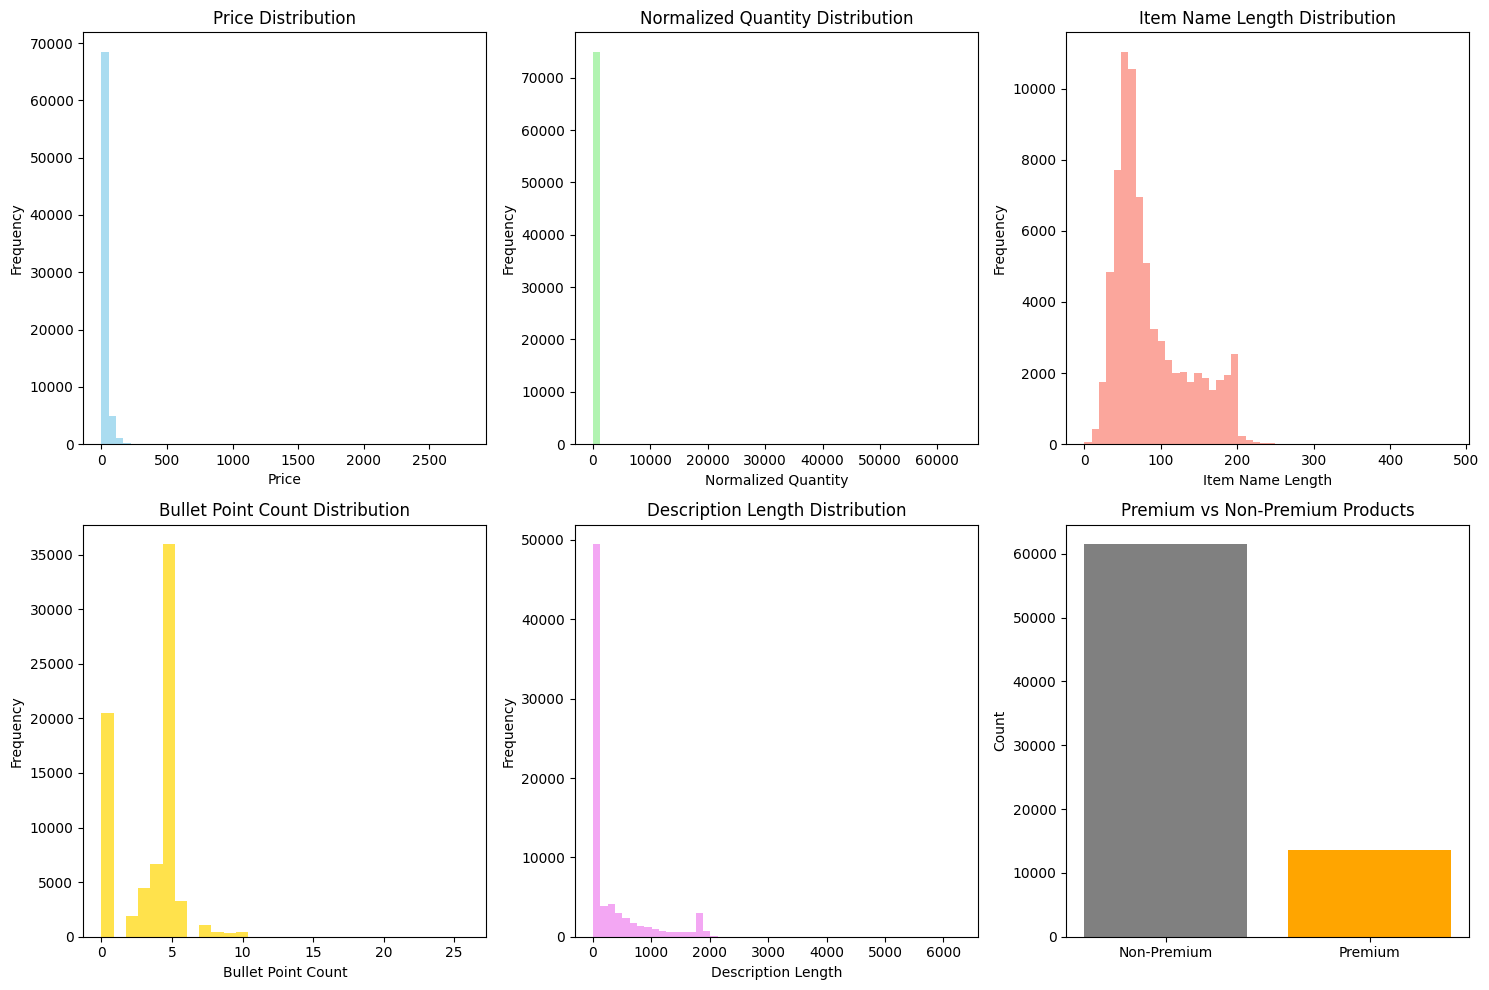

In [13]:
def plot_feature_distributions(features_df: pd.DataFrame):
    """Plot distributions of key features"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Price distribution
    axes[0, 0].hist(features_df['price'], bins=50, alpha=0.7, color='skyblue')
    axes[0, 0].set_title('Price Distribution')
    axes[0, 0].set_xlabel('Price')
    axes[0, 0].set_ylabel('Frequency')
    
    # Normalized quantity distribution
    axes[0, 1].hist(features_df['normalized_quantity'], bins=50, alpha=0.7, color='lightgreen')
    axes[0, 1].set_title('Normalized Quantity Distribution')
    axes[0, 1].set_xlabel('Normalized Quantity')
    axes[0, 1].set_ylabel('Frequency')
    
    # Item name length distribution
    axes[0, 2].hist(features_df['item_name_length'], bins=50, alpha=0.7, color='salmon')
    axes[0, 2].set_title('Item Name Length Distribution')
    axes[0, 2].set_xlabel('Item Name Length')
    axes[0, 2].set_ylabel('Frequency')
    
    # Bullet point count distribution
    axes[1, 0].hist(features_df['enhanced_bullet_point_count'], bins=30, alpha=0.7, color='gold')
    axes[1, 0].set_title('Bullet Point Count Distribution')
    axes[1, 0].set_xlabel('Bullet Point Count')
    axes[1, 0].set_ylabel('Frequency')
    
    # Description length distribution
    axes[1, 1].hist(features_df['detailed_description_length'], bins=50, alpha=0.7, color='violet')
    axes[1, 1].set_title('Description Length Distribution')
    axes[1, 1].set_xlabel('Description Length')
    axes[1, 1].set_ylabel('Frequency')
    
    # Premium products count
    premium_counts = features_df['is_premium'].value_counts()
    axes[1, 2].bar(['Non-Premium', 'Premium'], premium_counts.values, color=['gray', 'orange'])
    axes[1, 2].set_title('Premium vs Non-Premium Products')
    axes[1, 2].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()

plot_feature_distributions(features_df)

### Correlation analysis

Top 10 features positively correlated with price:
  detailed_description_length: 0.180
  detailed_description_word_count: 0.180
  detailed_sentence_count: 0.176
  detailed_confidence_indicators: 0.157
  detailed_avg_word_length: 0.135
  word_count: 0.094
  item_name_length: 0.087
  detailed_positive_word_count: 0.086
  value: 0.066
  normalized_quantity: 0.065

Top 10 features negatively correlated with price:
  normalized_quantity: 0.065
  detailed_marketing_language_score: 0.065
  enhanced_total_bullet_length: 0.053
  detailed_technical_term_count: 0.046
  enhanced_avg_bullet_length: 0.044
  enhanced_quality_indicators: 0.042
  enhanced_premium_keywords_count: 0.036
  enhanced_bullet_point_count: 0.018
  enhanced_extracted_dimensions: 0.011
  enhanced_extracted_weight: -0.000


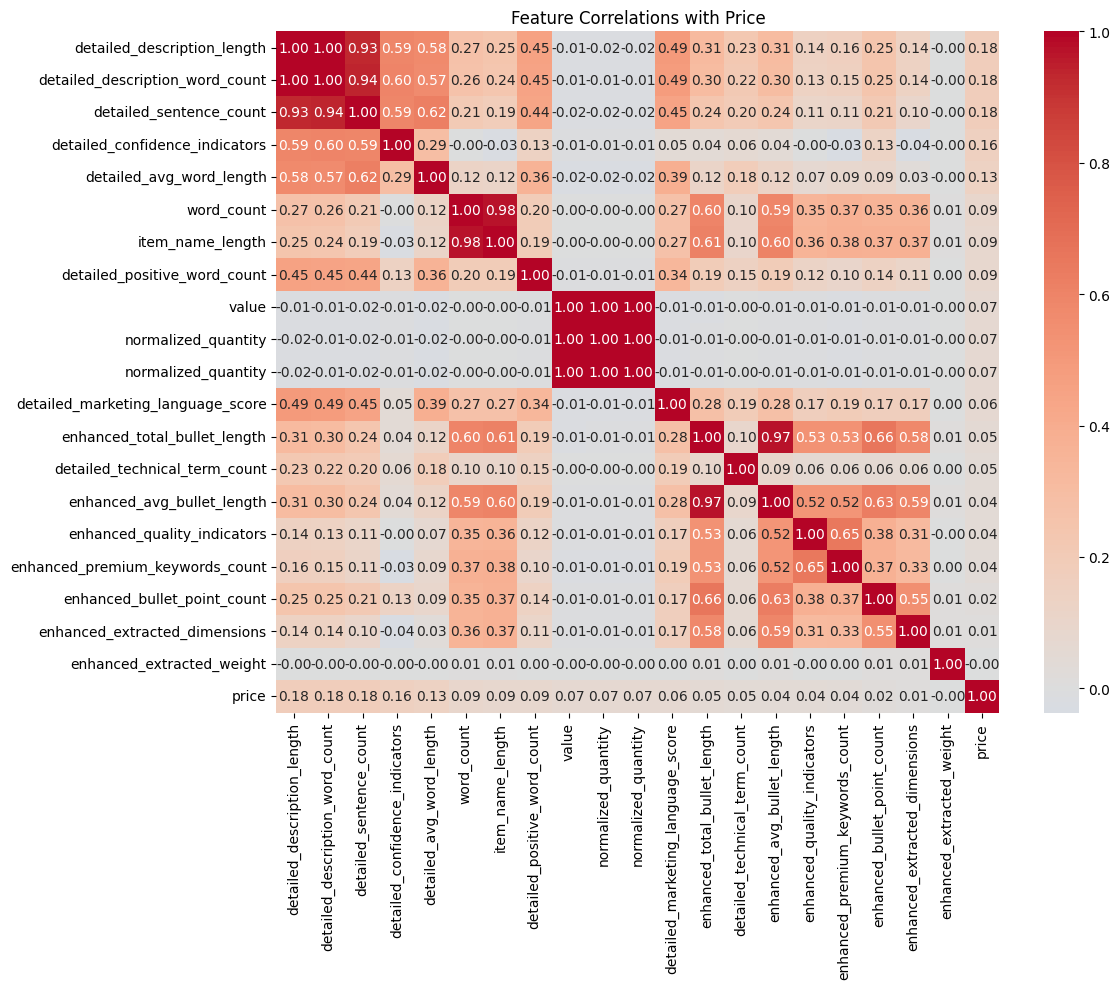

In [14]:
def analyze_correlations(features_df: pd.DataFrame):
    """Analyze correlations between features and price"""
    # Select numerical features for correlation analysis
    numerical_features = features_df.select_dtypes(include=[np.number]).columns
    numerical_features = [f for f in numerical_features if f not in ['sample_id', 'price']]
    
    # Calculate correlations with price
    correlations = features_df[numerical_features + ['price']].corr()['price'].sort_values(ascending=False)
    
    print("Top 10 features positively correlated with price:")
    for feature, corr in correlations[1:11].items():  # Skip price itself
        print(f"  {feature}: {corr:.3f}")
    
    print("\nTop 10 features negatively correlated with price:")
    for feature, corr in correlations[-10:].items():
        print(f"  {feature}: {corr:.3f}")
    
    # Plot top correlations
    top_features = list(correlations[1:11].index) + list(correlations[-10:].index)
    corr_matrix = features_df[top_features + ['price']].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Feature Correlations with Price')
    plt.tight_layout()
    plt.show()
    
    return correlations

correlations = analyze_correlations(features_df)

### Save processed feature

In [15]:
def save_processed_data(features_df: pd.DataFrame, feature_engineer: FeatureEngineer):
    """Save processed features and feature engineer"""
    # Save features to CSV
    features_df.to_csv('processed_features.csv', index=False)
    print("Processed features saved to 'processed_features.csv'")
    
    # Save feature engineer (you can use pickle or joblib in practice)
    # For now, we'll just note which features were created
    feature_info = {
        'core_features': [col for col in features_df.columns if not col.startswith(('enhanced_', 'detailed_')) 
                         and col not in ['sample_id', 'price', 'raw_text']],
        'enhanced_features': [col for col in features_df.columns if col.startswith('enhanced_')],
        'detailed_features': [col for col in features_df.columns if col.startswith('detailed_')]
    }
    
    print("\nFeature Engineering Summary:")
    print(f"Core features: {len(feature_info['core_features'])}")
    print(f"Enhanced features: {len(feature_info['enhanced_features'])}") 
    print(f"Detailed features: {len(feature_info['detailed_features'])}")
    print(f"Total features: {len(feature_info['core_features']) + len(feature_info['enhanced_features']) + len(feature_info['detailed_features'])}")
    
    return feature_info

feature_info = save_processed_data(features_df, feature_engineer)


Processed features saved to 'processed_features.csv'

Feature Engineering Summary:
Core features: 10
Enhanced features: 10
Detailed features: 10
Total features: 30


### Summary statistics

In [16]:
def print_summary_statistics(features_df: pd.DataFrame):
    """Print summary statistics of the processed data"""
    print("\n=== SUMMARY STATISTICS ===")
    print(f"Total samples: {len(features_df)}")
    print(f"Total features: {len(features_df.columns) - 2}")  # Excluding sample_id and price
    
    # Price statistics
    print(f"\nPrice Statistics:")
    print(f"  Min price: ${features_df['price'].min():.2f}")
    print(f"  Max price: ${features_df['price'].max():.2f}")
    print(f"  Mean price: ${features_df['price'].mean():.2f}")
    print(f"  Median price: ${features_df['price'].median():.2f}")
    print(f"  Std price: ${features_df['price'].std():.2f}")
    
    # Feature availability
    bullet_point_availability = (features_df['enhanced_bullet_point_count'] > 0).sum() / len(features_df) * 100
    description_availability = (features_df['detailed_description_length'] > 0).sum() / len(features_df) * 100
    
    print(f"\nFeature Availability:")
    print(f"  Samples with bullet points: {bullet_point_availability:.1f}%")
    print(f"  Samples with descriptions: {description_availability:.1f}%")
    print(f"  Premium products: {features_df['is_premium'].sum()} ({features_df['is_premium'].mean()*100:.1f}%)")
    
    # Category distribution
    print(f"\nProduct Category Distribution:")
    category_counts = features_df['category'].value_counts()
    for category, count in category_counts.items():
        percentage = (count / len(features_df)) * 100
        print(f"  {category}: {count} ({percentage:.1f}%)")

print_summary_statistics(features_df)

print("\nText processing completed successfully!")


=== SUMMARY STATISTICS ===
Total samples: 75000
Total features: 30

Price Statistics:
  Min price: $0.13
  Max price: $2796.00
  Mean price: $23.65
  Median price: $14.00
  Std price: $33.38

Feature Availability:
  Samples with bullet points: 72.6%
  Samples with descriptions: 43.4%
  Premium products: 13524 (18.0%)

Product Category Distribution:
  other: 39656 (52.9%)
  beverage: 15586 (20.8%)
  condiment: 7054 (9.4%)
  snack: 6899 (9.2%)
  grain: 3974 (5.3%)
  supplement: 1411 (1.9%)
  personal_care: 420 (0.6%)

Text processing completed successfully!
